# Emotion Detection with ResNet50 in PyTorch

**Architecture:** ResNet50 built from scratch, without pretrained weights.  
**Dataset:** `./dataset` with `train`, `validation`, and `test` folders.

---
## 1. Import Libraries

In [1]:
import json
import os
import random
from collections import defaultdict

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from torch import nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import warnings
warnings.filterwarnings('ignore')

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available:   {torch.cuda.is_available()}')
print(f'MPS available:    {torch.backends.mps.is_available()}')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device:           {DEVICE}')

PyTorch version: 2.12.0
CUDA available:   False
MPS available:    True
Device:           mps


---
## 2. Dataset Configuration & Loading

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────

DATASET_ROOT = '../dataset'
TRAIN_DIR = os.path.join(DATASET_ROOT, 'train')
VALIDATION_DIR = os.path.join(DATASET_ROOT, 'validation')
TEST_DIR = os.path.join(DATASET_ROOT, 'test')

IMG_SIZE = 48
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 1e-3
NUM_CLASSES = 8
NUM_WORKERS = 0

EMOTIONS = sorted(os.listdir(TRAIN_DIR))
print(f'Detected {len(EMOTIONS)} emotion classes: {EMOTIONS}')

for split_name, path in [('Train', TRAIN_DIR), ('Validation', VALIDATION_DIR), ('Test', TEST_DIR)]:
    total = sum(len(os.listdir(os.path.join(path, emotion))) for emotion in EMOTIONS)
    print(f'{split_name:12s}: {total:,} images  ({total // len(EMOTIONS)} per class)')

Detected 8 emotion classes: ['Anger', 'Contempt', 'Disgust', 'Fear', 'Happiness', 'Neutral', 'Sadness', 'Surprise']
Train       : 16,000 images  (2000 per class)
Validation  : 3,200 images  (400 per class)
Test        : 3,200 images  (400 per class)


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# DATASETS AND DATALOADERS
# ─────────────────────────────────────────────────────────────────────────────

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomAffine(
        degrees=15,
        translate=(0.1, 0.1),
        shear=0.1,
        scale=(0.9, 1.1),
    ),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
validation_dataset = datasets.ImageFolder(VALIDATION_DIR, transform=val_test_transforms)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=val_test_transforms)

class_to_idx = train_dataset.class_to_idx
idx_to_class = {idx: name for name, idx in class_to_idx.items()}
class_names = [idx_to_class[idx] for idx in range(NUM_CLASSES)]

pin_memory = DEVICE.type == 'cuda'
loader_kwargs = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=pin_memory)
train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
    **loader_kwargs,
)
validation_loader = DataLoader(
    validation_dataset,
    shuffle=False,
    **loader_kwargs,
)
test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    **loader_kwargs,
)

print('\nClass → Index mapping:')
for name, idx in class_to_idx.items():
    print(f'  {idx}: {name}')

print(f'\nTrain samples:      {len(train_dataset):,}')
print(f'Validation samples: {len(validation_dataset):,}')
print(f'Test samples:       {len(test_dataset):,}')


Class → Index mapping:
  0: Anger
  1: Contempt
  2: Disgust
  3: Fear
  4: Happiness
  5: Neutral
  6: Sadness
  7: Surprise

Train samples:      16,000
Validation samples: 3,200
Test samples:       3,200


---
## 3. Data Visualization

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# GENERATE PREDICTIONS ON TEST SET
# ─────────────────────────────────────────────────────────────────────────────

required_names = {'checkpoint_path', 'model', 'predict_loader', 'test_loader'}
if required_names.issubset(globals()):
    if os.path.exists(checkpoint_path):
        best_checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
        model.load_state_dict(best_checkpoint['model_state_dict'])
        print(f"Loaded best checkpoint from epoch {best_checkpoint['epoch']}.")

    print('Generating predictions on test set ...')
    y_prob, y_true, y_pred = predict_loader(test_loader)

    print(f'\nTrue labels shape : {y_true.shape}')
    print(f'Pred labels shape : {y_pred.shape}')
else:
    print('Skipping test-set prediction preview until the model and training utilities are defined.')

Skipping test-set prediction preview until the model and training utilities are defined.


---
## 4. Build ResNet50 from Scratch

**ResNet (Deep Residual Learning for Image Recognition)** introduces skip connections (shortcuts) that bypass one or more layers, allowing gradients to flow directly through the network.  
For a layer **ℓ**, the output is: $x_{\ell+1} = F(x_\ell, \{W_\ell\}) + x_\ell$

This solves the **vanishing gradient problem**, enabling training of very deep networks and achieving better accuracy than shallower counterparts.

**ResNet50 uses Bottleneck blocks** — each block has 3 convolution layers (1×1, 3×3, 1×1) instead of 2:

**ResNet50 configuration:**
| Stage | # Bottleneck Blocks | Output Channels |
|-------|--------------------|-----------------|
| Conv1 (stem) | — | 64 |
| Layer 1 | 3 | 256 |
| Layer 2 | 4 | 512 |
| Layer 3 | 6 | 1024 |
| Layer 4 | 3 | 2048 |

Adapted for **48×48 input** (smaller than ImageNet 224×224 — stem stride & max-pool adjusted to preserve spatial resolution).

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# RESNET50 BUILT FROM SCRATCH IN PYTORCH
# ─────────────────────────────────────────────────────────────────────────────

class BottleneckBlock(nn.Module):
    """ResNet Bottleneck block: 1×1 → 3×3 → 1×1 Conv with a residual shortcut.

    The expansion factor of 4 means the final output channels = planes * 4.
    A projection shortcut (1×1 conv) is added when the number of channels or
    spatial dimensions change.
    """

    expansion: int = 4

    def __init__(
        self,
        in_channels: int,
        planes: int,
        stride: int = 1,
        downsample: nn.Module | None = None,
    ) -> None:
        super().__init__()
        # 1×1 conv — reduce channels
        self.conv1 = nn.Conv2d(in_channels, planes, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        # 3×3 conv — spatial processing
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        # 1×1 conv — expand channels
        self.conv3 = nn.Conv2d(planes, planes * self.expansion, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(planes * self.expansion)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = x

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        return self.relu(out)


class ResNet50Scratch(nn.Module):
    """
    ResNet50 built from scratch in PyTorch, adapted for 48×48 grayscale-sourced
    (3-channel) emotion images.

    The standard ResNet50 uses a 7×7 Conv stem with stride=2 followed by
    MaxPool (stride=2), reducing 224 → 56.  For 48×48 inputs we use a
    smaller 3×3 stem with stride=1 and no max-pool so the spatial map
    (48 → 6 after four stride-2 residual layers) stays large enough.

    Architecture:
        Stem  : 3×3 Conv-64, BN, ReLU               48×48 → 48×48
        Layer1: 3 × Bottleneck(64  → 256 ),  stride=1   48×48 → 48×48
        Layer2: 4 × Bottleneck(128 → 512 ),  stride=2   48×48 → 24×24
        Layer3: 6 × Bottleneck(256 → 1024),  stride=2   24×24 → 12×12
        Layer4: 3 × Bottleneck(512 → 2048),  stride=2   12×12 →  6×6
        AdaptiveAvgPool → 1×1
        Classifier: 2048 → num_classes
    """

    def __init__(
        self,
        input_channels: int = 3,
        num_classes: int = 8,
        dropout_rate: float = 0.3,
    ) -> None:
        super().__init__()
        self.in_channels = 64

        # ── Stem ──────────────────────────────────────────────────────────────
        # Smaller 3×3 stem (no stride-2 / no max-pool) to preserve 48×48 detail
        self.stem_conv = nn.Conv2d(input_channels, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.stem_bn   = nn.BatchNorm2d(64)
        self.stem_relu = nn.ReLU(inplace=True)

        # ── Residual layers ───────────────────────────────────────────────────
        self.layer1 = self._make_layer(planes=64,  num_blocks=3, stride=1)
        self.layer2 = self._make_layer(planes=128, num_blocks=4, stride=2)
        self.layer3 = self._make_layer(planes=256, num_blocks=6, stride=2)
        self.layer4 = self._make_layer(planes=512, num_blocks=3, stride=2)

        # ── Head ──────────────────────────────────────────────────────────────
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout     = nn.Dropout(dropout_rate)
        self.classifier  = nn.Linear(512 * BottleneckBlock.expansion, num_classes)

        self.apply(self._init_weights)

    # ── Layer factory ─────────────────────────────────────────────────────────
    def _make_layer(
        self,
        planes: int,
        num_blocks: int,
        stride: int = 1,
    ) -> nn.Sequential:
        downsample = None
        out_channels = planes * BottleneckBlock.expansion

        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

        layers = [BottleneckBlock(self.in_channels, planes, stride=stride, downsample=downsample)]
        self.in_channels = out_channels

        for _ in range(1, num_blocks):
            layers.append(BottleneckBlock(self.in_channels, planes))

        return nn.Sequential(*layers)

    # ── Weight initialisation ─────────────────────────────────────────────────
    @staticmethod
    def _init_weights(module: nn.Module) -> None:
        if isinstance(module, nn.Conv2d):
            nn.init.kaiming_normal_(module.weight, nonlinearity='relu')
        elif isinstance(module, nn.BatchNorm2d):
            nn.init.constant_(module.weight, 1.0)
            nn.init.constant_(module.bias, 0.0)
        elif isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, 0.0, 0.01)
            nn.init.constant_(module.bias, 0.0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stem_relu(self.stem_bn(self.stem_conv(x)))

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        return self.classifier(x)


def build_resnet50(
    input_channels: int = 3,
    num_classes: int = 8,
    dropout_rate: float = 0.3,
) -> ResNet50Scratch:
    return ResNet50Scratch(
        input_channels=input_channels,
        num_classes=num_classes,
        dropout_rate=dropout_rate,
    )


model = build_resnet50(
    input_channels=3,
    num_classes=NUM_CLASSES,
    dropout_rate=0.3,
).to(DEVICE)

num_parameters = sum(parameter.numel() for parameter in model.parameters())
print(model)
print(f'\nTrainable parameters: {num_parameters:,}')

ResNet50Scratch(
  (stem_conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (stem_relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BottleneckBlock(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
 

---
## 5. Compile & Train the Model

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# OPTIMISATION, SCHEDULING, AND HELPER FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────

criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)
checkpoint_path = 'best_resnet50_emotion.pt'


def run_epoch(loader, training=True):
    if training:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=pin_memory)
        labels = labels.to(DEVICE, non_blocking=pin_memory)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            outputs = model(images)
            loss = criterion(outputs, labels)
            if training:
                loss.backward()
                optimizer.step()

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        predictions = outputs.argmax(dim=1)
        running_correct += (predictions == labels).sum().item()
        running_total += batch_size

    avg_loss = running_loss / running_total
    avg_acc = running_correct / running_total
    return avg_loss, avg_acc


def predict_loader(loader):
    model.eval()
    all_probs = []
    all_true = []
    all_pred = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=pin_memory)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = probs.argmax(dim=1)

            all_probs.append(probs.cpu().numpy())
            all_true.append(labels.numpy())
            all_pred.append(preds.cpu().numpy())

    y_prob = np.concatenate(all_probs, axis=0)
    y_true = np.concatenate(all_true, axis=0)
    y_pred = np.concatenate(all_pred, axis=0)
    return y_prob, y_true, y_pred


print('Training utilities ready.')

Training utilities ready.


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# TRAIN
# ─────────────────────────────────────────────────────────────────────────────

history = defaultdict(list)
best_val_acc = 0.0
best_val_loss = float('inf')
best_val_acc_epoch = 0
best_val_loss_epoch = 0
patience = 10
epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, training=True)
    val_loss, val_acc = run_epoch(validation_loader, training=False)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_val_acc_epoch = epoch
        epochs_without_improvement = 0
        torch.save(
            {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_val_acc': best_val_acc,
                'class_to_idx': class_to_idx,
                'img_size': IMG_SIZE,
                'num_classes': NUM_CLASSES,
            },
            checkpoint_path,
        )
    else:
        epochs_without_improvement += 1

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_loss_epoch = epoch

    print(
        f'Epoch {epoch:02d}/{EPOCHS:02d} | '
        f'train_loss={train_loss:.4f} train_acc={train_acc:.4f} | '
        f'val_loss={val_loss:.4f} val_acc={val_acc:.4f} | '
        f'lr={optimizer.param_groups[0]["lr"]:.2e}'
    )

    if epochs_without_improvement >= patience:
        print(f'Early stopping triggered after {epoch} epochs.')
        break

if os.path.exists(checkpoint_path):
    best_checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(best_checkpoint['model_state_dict'])
    print(f'\nLoaded best model from epoch {best_checkpoint["epoch"]} with val accuracy {best_checkpoint["best_val_acc"]:.4f}.')

print('\n✅ Training complete!')

Epoch 01/50 | train_loss=1.3971 train_acc=0.4764 | val_loss=1.5034 val_acc=0.5231 | lr=1.00e-03
Epoch 02/50 | train_loss=0.4679 train_acc=0.8375 | val_loss=1.1823 val_acc=0.6806 | lr=1.00e-03
Epoch 03/50 | train_loss=0.2555 train_acc=0.9131 | val_loss=1.5378 val_acc=0.6306 | lr=1.00e-03
Epoch 04/50 | train_loss=0.1707 train_acc=0.9436 | val_loss=1.2429 val_acc=0.7444 | lr=1.00e-03
Epoch 05/50 | train_loss=0.1490 train_acc=0.9501 | val_loss=1.3629 val_acc=0.7100 | lr=1.00e-03
Epoch 06/50 | train_loss=0.1204 train_acc=0.9598 | val_loss=0.8113 val_acc=0.7578 | lr=1.00e-03
Epoch 07/50 | train_loss=0.0941 train_acc=0.9676 | val_loss=1.0113 val_acc=0.7325 | lr=1.00e-03
Epoch 08/50 | train_loss=0.1018 train_acc=0.9661 | val_loss=1.2253 val_acc=0.7009 | lr=1.00e-03
Epoch 09/50 | train_loss=0.0790 train_acc=0.9744 | val_loss=1.9962 val_acc=0.6706 | lr=1.00e-03
Epoch 10/50 | train_loss=0.0926 train_acc=0.9699 | val_loss=1.2907 val_acc=0.7562 | lr=1.00e-03
Epoch 11/50 | train_loss=0.0722 train_ac

---
## 6. Training vs Validation — Accuracy & Loss Curves

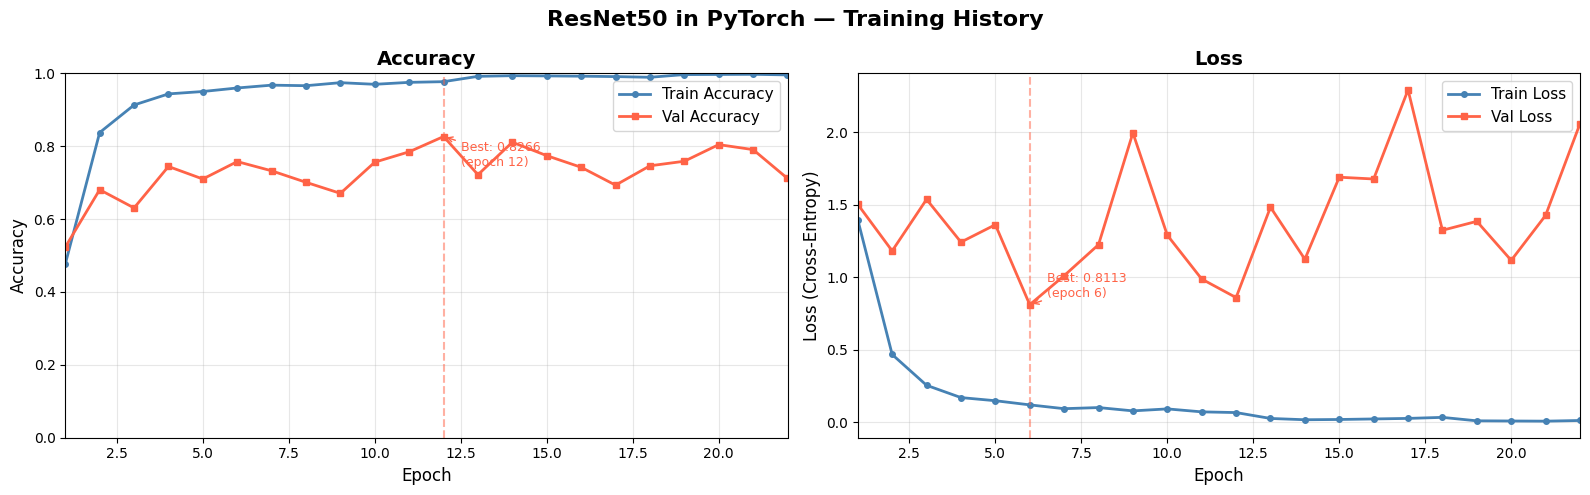

Plot saved as training_curves.png


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# TRAINING vs VALIDATION — ACCURACY & LOSS CURVES
# ─────────────────────────────────────────────────────────────────────────────

epochs_ran = range(1, len(history['train_acc']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('ResNet50 in PyTorch — Training History', fontsize=16, fontweight='bold')

ax = axes[0]
ax.plot(epochs_ran, history['train_acc'], color='steelblue', linewidth=2, marker='o', markersize=4, label='Train Accuracy')
ax.plot(epochs_ran, history['val_acc'], color='tomato', linewidth=2, marker='s', markersize=4, label='Val Accuracy')
ax.set_title('Accuracy', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(1, len(epochs_ran))
ax.set_ylim(0, 1)
ax.axvline(x=best_val_acc_epoch, color='tomato', linestyle='--', alpha=0.5)
ax.annotate(
    f'Best: {best_val_acc:.4f}\n(epoch {best_val_acc_epoch})',
    xy=(best_val_acc_epoch, best_val_acc),
    xytext=(best_val_acc_epoch + 0.5, max(0.05, best_val_acc - 0.08)),
    fontsize=9,
    color='tomato',
    arrowprops=dict(arrowstyle='->', color='tomato'),
)

ax = axes[1]
ax.plot(epochs_ran, history['train_loss'], color='steelblue', linewidth=2, marker='o', markersize=4, label='Train Loss')
ax.plot(epochs_ran, history['val_loss'], color='tomato', linewidth=2, marker='s', markersize=4, label='Val Loss')
ax.set_title('Loss', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss (Cross-Entropy)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(1, len(epochs_ran))
ax.axvline(x=best_val_loss_epoch, color='tomato', linestyle='--', alpha=0.5)
ax.annotate(
    f'Best: {best_val_loss:.4f}\n(epoch {best_val_loss_epoch})',
    xy=(best_val_loss_epoch, best_val_loss),
    xytext=(best_val_loss_epoch + 0.5, best_val_loss + 0.05),
    fontsize=9,
    color='tomato',
    arrowprops=dict(arrowstyle='->', color='tomato'),
)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as training_curves.png')

---
## 7. Performance Metrics

Evaluate on the **held-out test set** (never seen during training or validation).

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# GENERATE PREDICTIONS ON TEST SET
# ─────────────────────────────────────────────────────────────────────────────

if 'predict_loader' not in globals():
    raise RuntimeError('Run the training utilities cell before this evaluation cell.')

if os.path.exists(checkpoint_path):
    best_checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(best_checkpoint['model_state_dict'])
    print(f"Loaded best checkpoint from epoch {best_checkpoint['epoch']}.")

print('Generating predictions on test set ...')
y_prob, y_true, y_pred = predict_loader(test_loader)

# Map indices back to class names
class_names = [idx_to_class[i] for i in range(NUM_CLASSES)]

print(f'\nTrue labels shape : {y_true.shape}')
print(f'Pred labels shape : {y_pred.shape}')

Loaded best checkpoint from epoch 12.
Generating predictions on test set ...

True labels shape : (3200,)
Pred labels shape : (3200,)


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# OVERALL METRICS
# ─────────────────────────────────────────────────────────────────────────────

acc = accuracy_score(y_true, y_pred)
prec_w = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec_w = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1_w = f1_score(y_true, y_pred, average='weighted', zero_division=0)
prec_m = precision_score(y_true, y_pred, average='macro', zero_division=0)
rec_m = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1_m = f1_score(y_true, y_pred, average='macro', zero_division=0)

print('=' * 60)
print('           OVERALL PERFORMANCE METRICS (Test Set)')
print('=' * 60)
print(f'  Accuracy                        : {acc:.4f}  ({acc * 100:.2f}%)')
print()
print(f'  Weighted Precision               : {prec_w:.4f}')
print(f'  Weighted Recall                  : {rec_w:.4f}')
print(f'  Weighted F1-Score                : {f1_w:.4f}')
print()
print(f'  Macro Precision                  : {prec_m:.4f}')
print(f'  Macro Recall                     : {rec_m:.4f}')
print(f'  Macro F1-Score                   : {f1_m:.4f}')
print('=' * 60)

           OVERALL PERFORMANCE METRICS (Test Set)
  Accuracy                        : 0.8841  (88.41%)

  Weighted Precision               : 0.8998
  Weighted Recall                  : 0.8841
  Weighted F1-Score                : 0.8777

  Macro Precision                  : 0.8998
  Macro Recall                     : 0.8841
  Macro F1-Score                   : 0.8777


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# PER-CLASS CLASSIFICATION REPORT
# ─────────────────────────────────────────────────────────────────────────────

print('\nDetailed Classification Report:')
print('-' * 60)
report_str = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report_str)

report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)


Detailed Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

       Anger     0.8037    0.9825    0.8841       400
    Contempt     0.9592    1.0000    0.9792       400
     Disgust     0.9413    0.9625    0.9518       400
        Fear     1.0000    0.7950    0.8858       400
   Happiness     0.7809    0.9800    0.8692       400
     Neutral     0.7473    0.8575    0.7986       400
     Sadness     0.9706    0.4950    0.6556       400
    Surprise     0.9950    1.0000    0.9975       400

    accuracy                         0.8841      3200
   macro avg     0.8998    0.8841    0.8777      3200
weighted avg     0.8998    0.8841    0.8777      3200



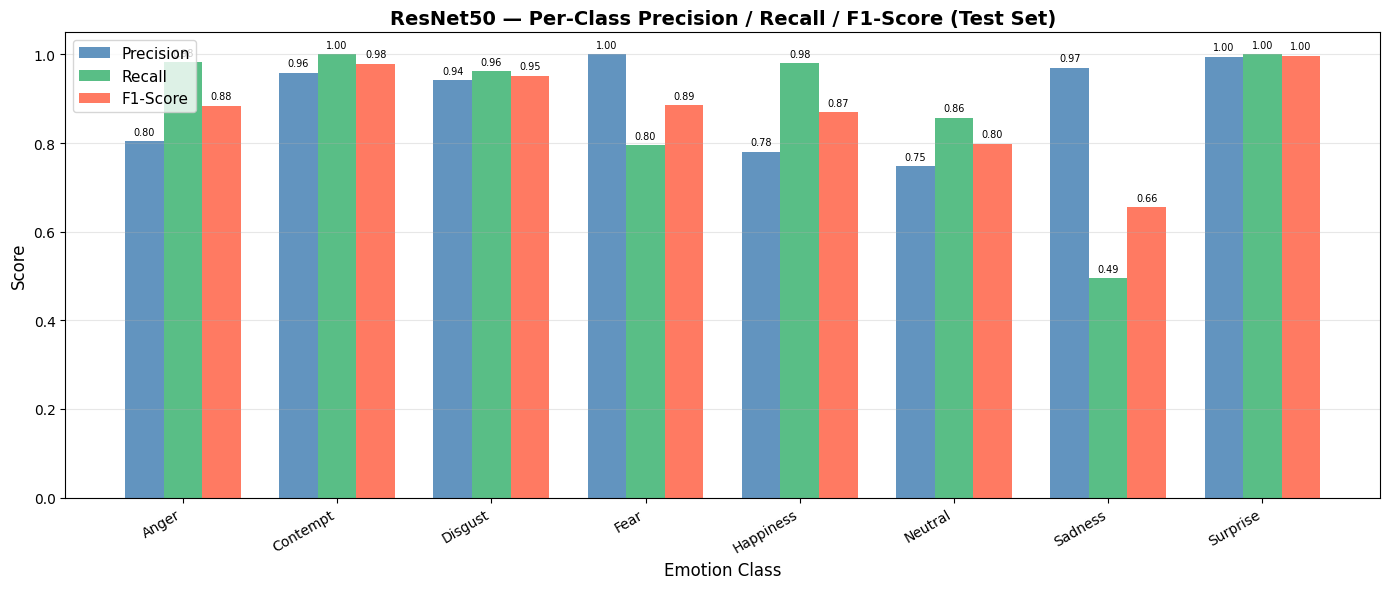

Plot saved as per_class_metrics.png


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# VISUALISE PER-CLASS METRICS (bar chart)
# ─────────────────────────────────────────────────────────────────────────────

per_class_precision = [report_dict[c]['precision'] for c in class_names]
per_class_recall    = [report_dict[c]['recall']    for c in class_names]
per_class_f1        = [report_dict[c]['f1-score']  for c in class_names]

x = np.arange(NUM_CLASSES)
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width, per_class_precision, width, label='Precision', color='steelblue',   alpha=0.85)
bars2 = ax.bar(x,         per_class_recall,    width, label='Recall',    color='mediumseagreen', alpha=0.85)
bars3 = ax.bar(x + width, per_class_f1,        width, label='F1-Score',  color='tomato',      alpha=0.85)

ax.set_title('ResNet50 — Per-Class Precision / Recall / F1-Score (Test Set)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Emotion Class', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=30, ha='right')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)
for bar in bars3:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as per_class_metrics.png')

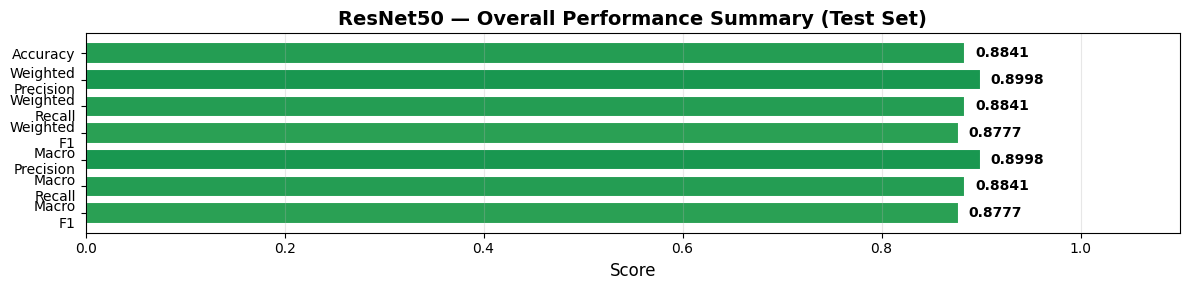

Plot saved as summary_metrics.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# PER-CLASS METRICS — BAR CHART
# ─────────────────────────────────────────────────────────────────────────────

per_class_precision = [report_dict[c]['precision'] for c in class_names]
per_class_recall = [report_dict[c]['recall'] for c in class_names]
per_class_f1 = [report_dict[c]['f1-score'] for c in class_names]

x = np.arange(len(class_names))
width = 0.26

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width, per_class_precision, width, label='Precision', color='steelblue', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x, per_class_recall, width, label='Recall', color='mediumseagreen', alpha=0.85, edgecolor='white')
bars3 = ax.bar(x + width, per_class_f1, width, label='F1-Score', color='tomato', alpha=0.85, edgecolor='white')

ax.set_title('ResNet50 — Per-Class Metrics: Precision, Recall & F1-Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Emotion Class', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=30, ha='right', fontsize=11)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f'{height:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as per_class_metrics.png')

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# FINAL CONSOLIDATED SUMMARY TABLE
# ─────────────────────────────────────────────────────────────────────────────

print('\n' + '=' * 72)
print('                  FINAL PERFORMANCE SUMMARY — TEST SET')
print('=' * 72)
print(f"{'Metric':<40} {'Score':>10}")
print('-' * 52)
print(f"{'Accuracy':<40} {acc:>10.4f}")
print()
print(f"{'Weighted Avg Precision':<40} {prec_w:>10.4f}")
print(f"{'Weighted Avg Recall':<40} {rec_w:>10.4f}")
print(f"{'Weighted Avg F1-Score':<40} {f1_w:>10.4f}")
print()
print(f"{'Macro Avg Precision':<40} {prec_m:>10.4f}")
print(f"{'Macro Avg Recall':<40} {rec_m:>10.4f}")
print(f"{'Macro Avg F1-Score':<40} {f1_m:>10.4f}")
print('-' * 52)
print()
print('Per-Class F1-Scores:')
for cls, f1_value in zip(class_names, per_class_f1):
    bar = '█' * int(f1_value * 30)
    print(f'  {cls:<12} {f1_value:.4f}  {bar}')
print('=' * 72)
best_val_acc_text = f'{best_val_acc:.4f} (Epoch {best_val_acc_epoch})' if 'best_val_acc' in globals() else 'N/A (run training first)'
best_val_loss_text = f'{best_val_loss:.4f} (Epoch {best_val_loss_epoch})' if 'best_val_loss' in globals() else 'N/A (run training first)'
print(f'  Best Validation Accuracy : {best_val_acc_text}')
print(f'  Best Validation Loss     : {best_val_loss_text}')
print('=' * 72)

---
## 8. Confusion Matrix

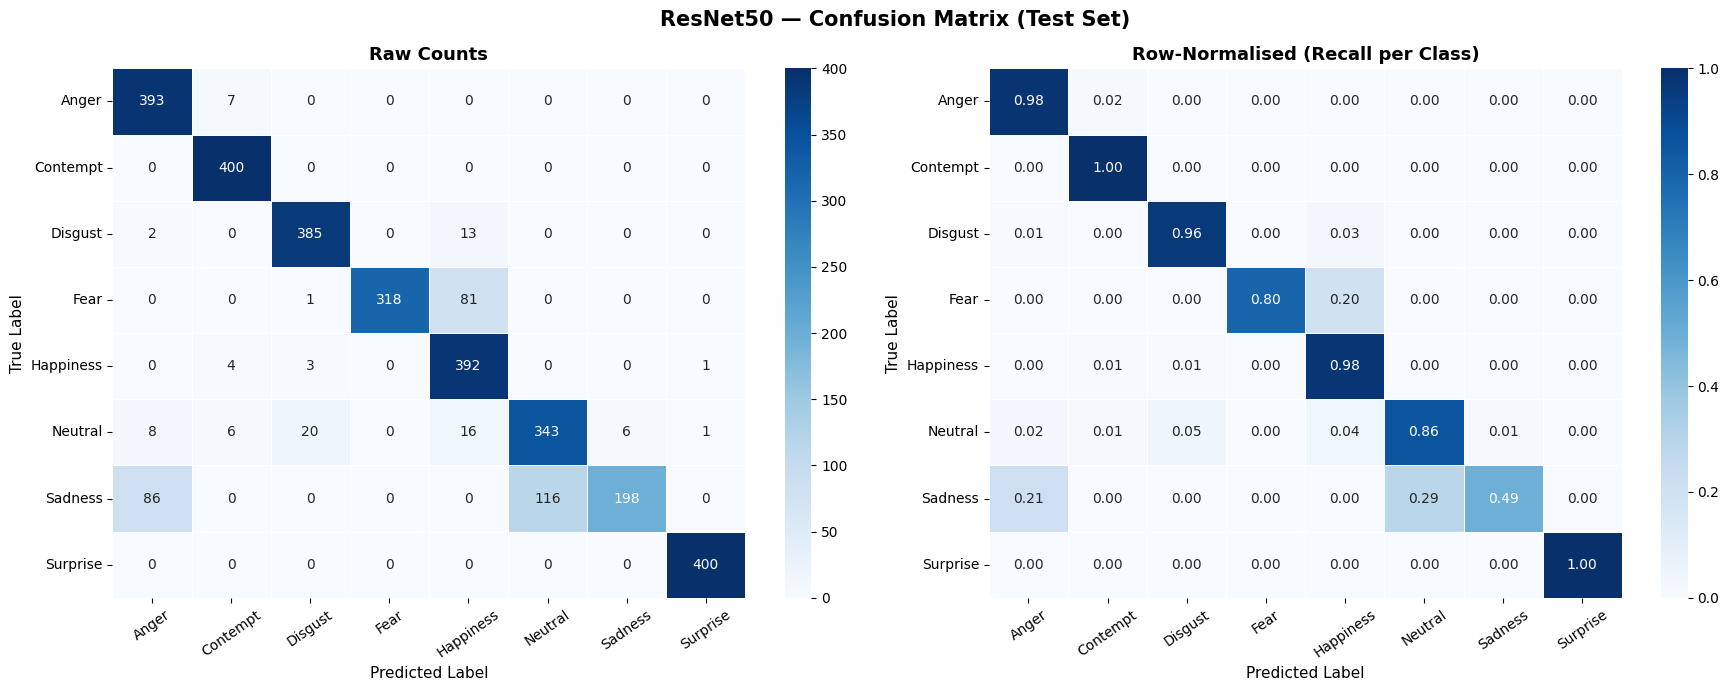

Plot saved as confusion_matrix.png


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFUSION MATRIX
# ─────────────────────────────────────────────────────────────────────────────

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalised

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('ResNet50 — Confusion Matrix (Test Set)', fontsize=15, fontweight='bold')

# Raw counts
sns.heatmap(
    cm,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names,
    linewidths=0.5, ax=axes[0],
)
axes[0].set_title('Raw Counts', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].tick_params(axis='x', rotation=35)
axes[0].tick_params(axis='y', rotation=0)

# Row-normalised
sns.heatmap(
    cm_norm,
    annot=True, fmt='.2f', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names,
    linewidths=0.5, vmin=0, vmax=1, ax=axes[1],
)
axes[1].set_title('Row-Normalised (Recall per Class)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)
axes[1].tick_params(axis='x', rotation=35)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as confusion_matrix.png')

---
## 9. Save Weights & Class Index Map

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# SAVE FINAL MODEL WEIGHTS
# ─────────────────────────────────────────────────────────────────────────────

weights_path = 'resnet50_emotion_weights.pt'
torch.save(model.state_dict(), weights_path)
print(f'Model weights saved → {weights_path}')

final_path = 'resnet50_emotion_final.pt'
torch.save(
    {
        'model_state_dict': model.state_dict(),
        'class_to_idx': class_to_idx,
        'idx_to_class': idx_to_class,
        'img_size': IMG_SIZE,
        'num_classes': NUM_CLASSES,
        'best_val_acc': best_val_acc,
        'best_val_acc_epoch': best_val_acc_epoch,
    },
    final_path,
)
print(f'Full checkpoint saved  → {final_path}')

class_index_path = 'class_indices.json'
with open(class_index_path, 'w') as f:
    json.dump(class_to_idx, f, indent=2)
print(f'Class index map saved  → {class_index_path}')

Model weights saved → resnet50_emotion_weights.pt
Full checkpoint saved  → resnet50_emotion_final.pt
Class index map saved  → class_indices.json


---
## Bonus: Quick Inference on a Single Image

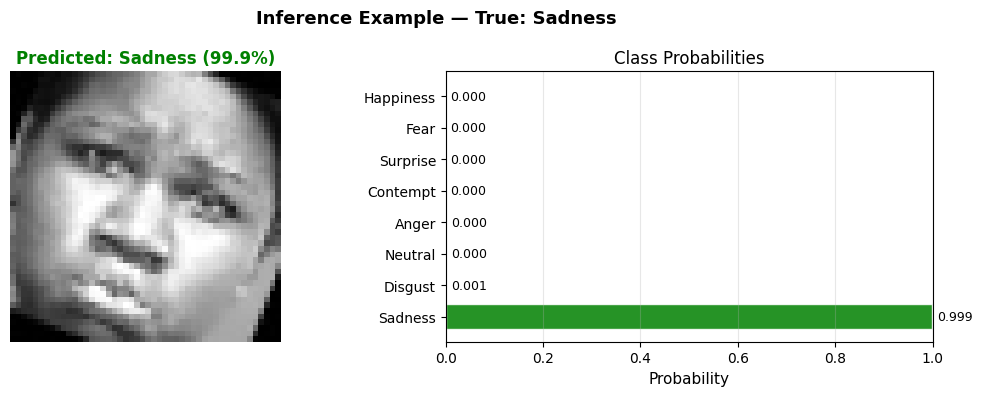

True label : Sadness
Predicted  : Sadness (confidence: 99.91%)
Result     : ✅ CORRECT


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# QUICK INFERENCE — predict emotion for one image
# ─────────────────────────────────────────────────────────────────────────────

def predict_emotion(img_path, model, idx_to_class, img_size=48, device=DEVICE):
    """Load an image, preprocess it, and return the predicted emotion."""
    image = Image.open(img_path).convert('RGB')
    image_tensor = val_test_transforms(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        probabilities = torch.softmax(model(image_tensor), dim=1)[0].cpu().numpy()

    pred_idx = int(np.argmax(probabilities))
    predicted_class = idx_to_class[pred_idx]
    confidence = float(probabilities[pred_idx])
    all_probs = {idx_to_class[i]: float(probabilities[i]) for i in range(len(probabilities))}
    return predicted_class, confidence, all_probs


sample_path, sample_label_idx = random.choice(test_dataset.samples)
sample_emotion = idx_to_class[sample_label_idx]
pred_class, confidence, all_probs = predict_emotion(sample_path, model, idx_to_class)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle(f'Inference Example — True: {sample_emotion}', fontsize=13, fontweight='bold')

img_display = Image.open(sample_path).convert('RGB')
axes[0].imshow(img_display)
color = 'green' if pred_class == sample_emotion else 'red'
axes[0].set_title(f'Predicted: {pred_class} ({confidence * 100:.1f}%)', color=color, fontsize=12, fontweight='bold')
axes[0].axis('off')

sorted_probs = dict(sorted(all_probs.items(), key=lambda item: item[1], reverse=True))
bar_colors = ['green' if class_name == sample_emotion else ('steelblue' if class_name != pred_class else 'tomato') for class_name in sorted_probs.keys()]
axes[1].barh(list(sorted_probs.keys()), list(sorted_probs.values()), color=bar_colors, alpha=0.85, edgecolor='white')
axes[1].set_xlim(0, 1)
axes[1].set_xlabel('Probability', fontsize=11)
axes[1].set_title('Class Probabilities', fontsize=12)
axes[1].grid(axis='x', alpha=0.3)
for i, (class_name, probability) in enumerate(sorted_probs.items()):
    axes[1].text(probability + 0.01, i, f'{probability:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()
print(f'True label : {sample_emotion}')
print(f'Predicted  : {pred_class} (confidence: {confidence * 100:.2f}%)')
correct = '✅ CORRECT' if pred_class == sample_emotion else '❌ INCORRECT'
print(f'Result     : {correct}')